# Fit of the resolution density

## Preliminaries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from matplotlib.ticker import AutoMinorLocator
import iminuit

## Definitions

Double-sided Crystal Ball density

In [2]:
def crystalball_double(x, mu, sigma, alphaL, nL, alphaR, nR):
    x = (x - mu) / sigma
    x = np.clip(x, -50, 50)

    # coefficients (log-safe)
    aL = np.exp(nL * np.log(nL / alphaL) - 0.5 * alphaL**2)
    bL = nL / alphaL - alphaL
    aR = np.exp(nR * np.log(nR / alphaR) - 0.5 * alphaR**2)
    bR = nR / alphaR - alphaR

    f = np.empty_like(x)
    left  = x <= -alphaL
    core  = (x > -alphaL) & (x <  alphaR)
    right = x >=  alphaR

    f[left]  = aL * np.power(np.maximum(bL - x[left],  0.0), -nL)
    f[core]  = np.exp(-0.5 * x[core]**2)
    f[right] = aR * np.power(np.maximum(bR + x[right], 0.0), -nR)
    return f


def crystalball_double_normed(x, mu, sigma, alphaL, nL, alphaR, nR, xmin=-np.inf, xmax=np.inf):

    f = crystalball_double(x, mu, sigma, alphaL, nL, alphaR, nR)
    # numerical normalisation
    if np.isinf(xmin) or np.isinf(xmax):
        xgrid = np.linspace(mu - 50*sigma, mu + 50*sigma, 2000)
    else:
        xgrid = np.linspace(xmin, xmax, 2000)
    fgrid = crystalball_double(xgrid, mu, sigma, alphaL, nL, alphaR, nR)
    norm = np.trapezoid(fgrid, xgrid)
    return f / norm


## Data as provided by LHCb 2020 (supplementary material)

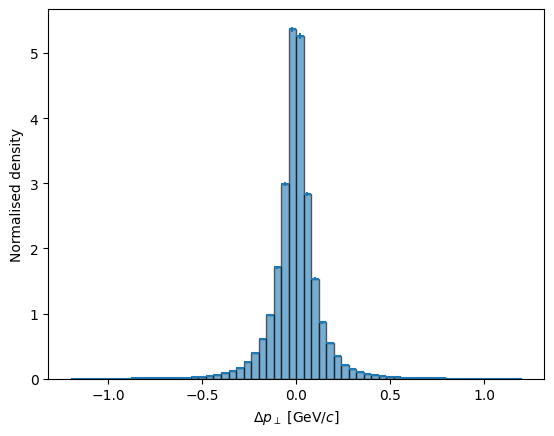

In [3]:
# histogram setup
bin_edges   = np.linspace(-1.2, 1.2, 61)        # 60 bins
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width   = bin_edges[1] - bin_edges[0]

# counts per bin
counts = np.array([
    1.02585,1.892549,2.357481,1.673578,1.195616,7.714344,6.956256,6.08624,11.14624,
    14.55873,11.58774,11.97618,13.86773,20.62657,34.70055,52.94374,60.49452,
    102.8932,143.2239,157.0008,250.0748,342.726,506.9189,768.7197,1190.905,
    1858.167,2988.735,5234.417,9120.084,16386.18,16084.24,8685.558,4688.71,
    2638.687,1661.417,1050.158,649.7015,458.5821,316.0372,230.3855,155.3931,
    137.6773,83.68854,62.9441,37.02073,37.21539,20.52301,18.7533,24.28236,
    13.33005,9.178684,5.788401,4.194178,7.650864,0.9782353,2.015617,5.199924,
    2.657357,2.127046,0.0
])

del_counts = np.sqrt(counts)

# normalised density (unit area)
N_total = counts.sum()
density = counts / (N_total * bin_width)
density_unc = del_counts / (N_total * bin_width)

# plot histogram
plt.errorbar(bin_centres, density, xerr=bin_width*0.5, yerr=density_unc,
             fmt='None', color='tab:blue')
plt.bar(bin_centres, density, width=bin_width, alpha=0.6, edgecolor='black')
plt.xlabel(r"$\Delta p_\perp$ [GeV/$c$]")
plt.ylabel("Normalised density")
plt.show()


LHCb provides 60 bins, one of which is zero. We exclude it from the $\chi^2$ function, since its associated uncertainty would be zero, too.

In [4]:
mask_threshold = 0.0001
mask = (density > mask_threshold) & ~np.isnan(density)
n_points = int(mask.sum())
print(f"Number of bins used = {n_points}")

def chi2_cb2(mu, sigma, alphaL, nL, alphaR, nR):
    # Evaluate normalised CB2 at bin centres
    p = crystalball_double_normed(bin_centres, mu, sigma, alphaL, nL, alphaR, nR,
                                  xmin=bin_edges[0], xmax=bin_edges[-1])
    chi2 = np.sum(((density[mask] - p[mask]) / density_unc[mask])**2)
    return chi2

Number of bins used = 59


We fit the density using ``iMinuit``.

In [5]:
m_cb2 = iminuit.Minuit(
    chi2_cb2,
    mu=0.005, sigma=0.11,
    alphaL=1.8, nL=3.5,
    alphaR=1.6, nR=4.0
)

# sensible limits
m_cb2.limits["mu"] = (-0.05, 0.05)
m_cb2.limits["sigma"] = (0.02, 0.40)
m_cb2.limits["alphaL"] = (0.5, 5.0)
m_cb2.limits["nL"] = (1.0, 10.0)
m_cb2.limits["alphaR"] = (0.5, 5.0)
m_cb2.limits["nR"] = (1.0, 10.0)

# optimisation settings
m_cb2.errordef = 1
m_cb2.strategy = 0
m_cb2.tol = 0.1

m_cb2.migrad()
m_cb2.hesse()

mu_cb2, sigma_cb2, alphaL_cb2, nL_cb2, alphaR_cb2, nR_cb2 = m_cb2.values

# compute χ² / dof / p-value
cb2_chi2_val = m_cb2.fval
cb2_dof = n_points - 6
p_cb2 = chi2.sf(cb2_chi2_val, cb2_dof)

print("\n===== Fit results =====")
print(f"mu       = {mu_cb2:.4f}")
print(f"sigma    = {sigma_cb2:.4f}")
print(f"alphaL, nL = {alphaL_cb2:.3f}, {nL_cb2:.3f}")
print(f"alphaR, nR = {alphaR_cb2:.3f}, {nR_cb2:.3f}")
print(f"Chi² = {cb2_chi2_val:.3f},  dof = {cb2_dof},  p = {p_cb2:.3g}")


===== Fit results =====
mu       = -0.0008
sigma    = 0.0427
alphaL, nL = 0.665, 7.590
alphaR, nR = 0.718, 6.558
Chi² = 67.247,  dof = 53,  p = 0.0902


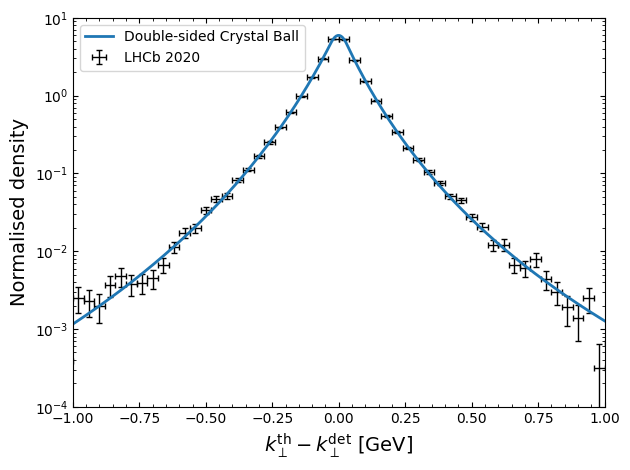

In [6]:
x_plot = np.linspace(bin_edges[0], bin_edges[-1], 400)
y_cb2 = crystalball_double_normed(x_plot,
                                  mu_cb2, sigma_cb2,
                                  alphaL_cb2, nL_cb2,
                                  alphaR_cb2, nR_cb2,
                                  xmin=bin_edges[0], xmax=bin_edges[-1])

fig, ax = plt.subplots()
ax.tick_params(direction='in', top=True, right=True, which='both')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.errorbar(bin_centres, density, xerr=bin_width*0.5, yerr=density_unc, fmt='None',                    # circular marker
    markersize=4,               # size of marker
    markerfacecolor='white',    # open circle
    markeredgecolor='k',        # black edge
    markeredgewidth=1.0,        # same as line thickness
    ecolor='k',                 # black error bars
    elinewidth=1.0,             # line thickness for error bars
    capsize=2,                  # small cross caps
    label="LHCb 2020"
)

ax.plot(x_plot, y_cb2, 'tab:blue', lw=2, label="Double-sided Crystal Ball")

# === text box with key info (inside figure) ===
mask_cutoff = 0.22   # (update automatically if needed)
info_text = (
    f"Mask cutoff: {mask_cutoff:.2f}\n"
    f"Bins used: {n_points}\n"
    f"p-value: {p_cb2:.3f}"
)

# match legend font size
legend_fontsize = plt.rcParams['legend.fontsize']

# ax.text(
#     0.05, 0.85, info_text,
#     transform=ax.transAxes,
#     fontsize=legend_fontsize,
#     va='top', ha='left',
#     bbox=dict(facecolor='white', edgecolor='grey', alpha=0.9, boxstyle='round,pad=0.3')
# )


ax.set_xlabel(r"$k_\perp^\mathrm{th} - k_\perp^\mathrm{det}$ [GeV]", fontsize = 14)
ax.set_ylabel("Normalised density", fontsize = 14)
ax.set_yscale('log')
ax.set_xlim(-1, 1)
ax.set_ylim(1e-4, 10)
ax.legend(loc = 'upper left')
fig.tight_layout()
fig.savefig("figures/resolution_fit.pdf")
fig.savefig("figures/resolution_fit.png")
plt.show()

In [7]:
# compute CB2 PDF values at all bin edges
pdf_edges = crystalball_double_normed(bin_edges,
                                      mu_cb2, sigma_cb2,
                                      alphaL_cb2, nL_cb2,
                                      alphaR_cb2, nR_cb2,
                                      xmin=bin_edges[0], xmax=bin_edges[-1])

# integrate numerically between successive edges
bin_areas = np.array([
    np.trapezoid(
        crystalball_double_normed(np.linspace(bin_edges[i], bin_edges[i+1], 200),
                                  mu_cb2, sigma_cb2,
                                  alphaL_cb2, nL_cb2,
                                  alphaR_cb2, nR_cb2,
                                  xmin=bin_edges[0], xmax=bin_edges[-1]),
        np.linspace(bin_edges[i], bin_edges[i+1], 200)
    )
    for i in range(len(bin_edges)-1)
])

covered_area = np.sum(bin_areas[mask])
fraction_covered = covered_area  # total CB2 area = 1

print(f"Fraction of total CB2 area covered by fitted bins = {fraction_covered:.3f}")


Fraction of total CB2 area covered by fitted bins = 1.000


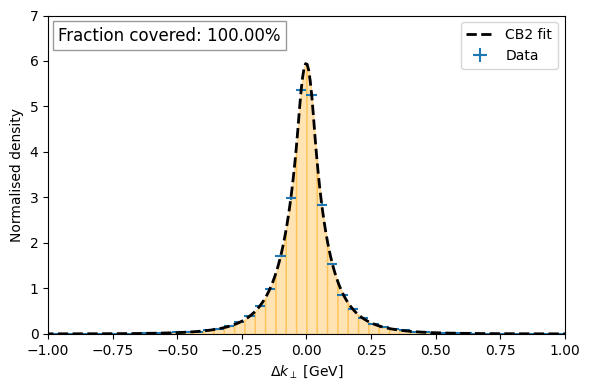

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

# main data and fitted CB2
ax.errorbar(bin_centres, density,
            xerr=bin_width*0.5, yerr=density_unc,
            fmt='None', color='tab:blue', label='Data')
ax.plot(x_plot,
        crystalball_double_normed(x_plot,
                                  mu_cb2, sigma_cb2,
                                  alphaL_cb2, nL_cb2,
                                  alphaR_cb2, nR_cb2,
                                  xmin=bin_edges[0], xmax=bin_edges[-1]),
        'k--', lw=2, label="CB2 fit")

# shade fitted bins (those in mask)
for i in range(len(bin_edges)-1):
    if mask[i]:
        x_left, x_right = bin_edges[i], bin_edges[i+1]
        x_fill = np.linspace(x_left, x_right, 50)
        y_fill = crystalball_double_normed(x_fill,
                                           mu_cb2, sigma_cb2,
                                           alphaL_cb2, nL_cb2,
                                           alphaR_cb2, nR_cb2,
                                           xmin=bin_edges[0], xmax=bin_edges[-1])
        ax.fill_between(x_fill, 0, y_fill, color='orange', alpha=0.3)

# annotate covered fraction
ax.text(0.02, 0.92,
        f"Fraction covered: {fraction_covered:.2%}",
        transform=ax.transAxes, fontsize=12,
        bbox=dict(facecolor='white', edgecolor='grey', alpha=0.8))

# labels and cosmetics
ax.set_xlabel(r"$\Delta k_\perp$ [GeV]")
ax.set_ylabel("Normalised density")
ax.set_xlim(-1, 1)
ax.set_ylim(0, 7)
ax.legend()
fig.tight_layout()

plt.show()
